In [5]:
import numpy as np
import tqdm
import matplotlib.pyplot as plt
import os

class Graph_PDCoEA():
    def __init__(self, alpha, beta, chi, l, n, t, p_ones=0.5):
        self.alpha = alpha
        self.beta = beta
        self.n = n
        self.l = l
        self.P = None
        self.Q = None
        self.History_P = np.empty(t)
        self.History_Q = np.empty(t)
        self.chi = chi
        self.t = t
        self.p_one = p_ones

    def bilinear(self,x,y):
        """ x: |x|
            y: |y|
                   """
        return y*(x - self.beta*self.n) - self.alpha*self.n*x
    def fitness(self,x,y):
        return (((x - self.n/2)**3 - 3*(self.alpha*self.n/2)**2*(x - self.n/2)) + ((y - self.n/2)**3 - 3*(self.alpha*self.n/2)**2*(y - self.n/2)))

    
    def selection(self,P_1, P_2):
        """ P_1,P_2: tuple of numpy arrays (X_i,Y_i)"""
        x_1,y_1 = P_1
        x_2,y_2 = P_2

        condition_1 = self.fitness(x_1.sum(axis=1),y_2.sum(axis=1)) >= self.fitness(x_1.sum(axis=1),y_1.sum(axis=1))
        condition_2 = self.fitness(x_1.sum(axis=1),y_1.sum(axis=1)) >= self.fitness(x_2.sum(axis=1),y_1.sum(axis=1))
        select = np.logical_and(condition_1,condition_2)

        self.P = np.where(select[:,None],x_1,x_2)
        self.Q = np.where(select[:,None],y_1,y_2)

        mutate_P = np.random.random(size=(self.l,self.n)) <= self.chi/self.n
        mutate_Q = np.random.random(size=(self.l,self.n)) <= self.chi/self.n

        self.P ^= mutate_P
        self.Q ^= mutate_Q



    def initialize_population(self):
            p = np.random.rand(self.l,1)
            self.P = (np.random.rand(self.l, self.n) < p).astype(int)
            self.Q = (np.random.rand(self.l, self.n) < 1 - p).astype(int)
    
    def sample_from_pop(self):
        idx_x1 = np.random.choice(self.l, size=self.l)
        idx_y1 = np.random.choice(self.l, size=self.l)
        P_1 = (self.P[idx_x1], self.Q[idx_y1])

        idx_x2 = np.random.choice(self.l, size=self.l)
        idx_y2 = np.random.choice(self.l, size=self.l)
        P_2 = (self.P[idx_x2], self.Q[idx_y2])

        return P_1, P_2
    def run(self):
        self.initialize_population()
        for t in tqdm.tqdm(range(self.t)):
            self.History_P[t] = self.P.sum(axis = 1).mean()
            self.History_Q[t] = self.Q.sum(axis = 1).mean()
            P_1,P_2 = self.sample_from_pop()
            self.selection(P_1,P_2)
            

    
    def print_best(self):
        print(self.P.sum(axis=1),self.Q.sum(axis=1))

   

    








    

        





In [6]:
alg = Graph_PDCoEA(0.5,0.6,1,10000,100,1000)
alg.run()

100%|██████████| 1000/1000 [01:05<00:00, 15.16it/s]


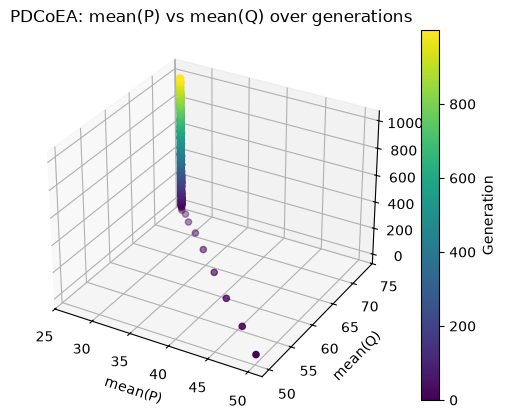

(<Figure size 640x480 with 2 Axes>,
 <Axes3D: title={'center': 'PDCoEA: mean(P) vs mean(Q) over generations'}, xlabel='mean(P)', ylabel='mean(Q)', zlabel='t'>)

In [7]:
import os
import matplotlib.pyplot as plt


def plot_points(P_mean_history, Q_mean_history, save_dir="plots", filename="pdcoea_scatter_9.png"):
        os.makedirs(save_dir, exist_ok=True)

        generations = range(len(P_mean_history))

        fig = plt.figure()
        ax = fig.add_subplot(projection='3d')
        sc = ax.scatter(P_mean_history, Q_mean_history, generations,
                         c=generations, cmap="viridis", s=20)
        ax.set_xlabel("mean(P)")
        ax.set_ylabel("mean(Q)")
        ax.set_zlabel("t")
        ax.set_title("PDCoEA: mean(P) vs mean(Q) over generations")
        fig.colorbar(sc, ax=ax, label="Generation")

        fig.savefig(os.path.join(save_dir, filename), dpi=150)
        plt.show()
        return fig, ax
plot_points(alg.History_P,alg.History_Q)

100%|██████████| 1000/1000 [00:57<00:00, 17.27it/s]


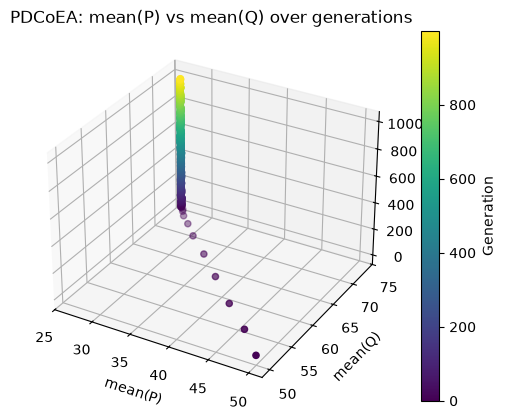

100%|██████████| 1000/1000 [01:02<00:00, 15.92it/s]


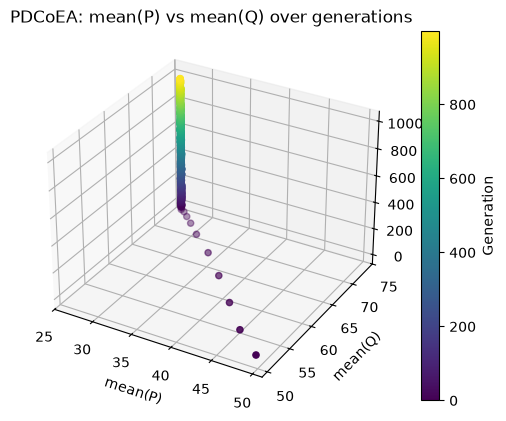

100%|██████████| 1000/1000 [01:00<00:00, 16.49it/s]


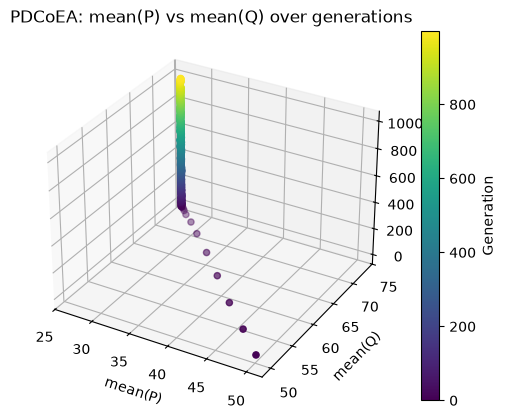

100%|██████████| 1000/1000 [01:09<00:00, 14.29it/s]


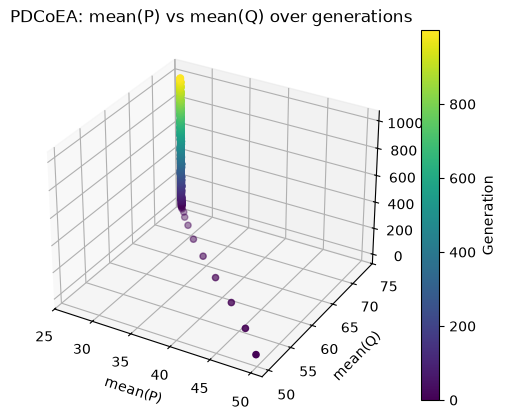

100%|██████████| 1000/1000 [01:09<00:00, 14.39it/s]


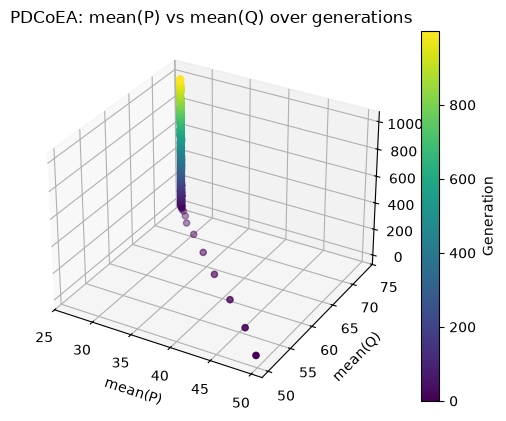

In [8]:
alg = Graph_PDCoEA(0.5,0.6,1,10000,100,1000,0.3)
for i in range(5):
    alg.run()
    plot_points(alg.History_P,alg.History_Q, save_dir = "plots_rand_p", filename=f"plot_{i}")